# Titanic Survival Prediction - Exploratory Data Analysis

What you'll learn:

    - How to load and inspect a dataset
    - Identifying missing values
    - Univariate and bivariate analysis
    - Correlation analysis
    - Visualizing survival patterns across different features


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

%matplotlib inline

## 2. Load the Datasets

In [2]:
df = pd.read_csv("data/titanic.csv")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset shape: 891 rows, 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Column Descriptions

| Column | Description |
|--------|-------------|
| PassengerId | Unique ID for each passenger |
| Survived | 0 = Did not survive, 1 = Survived |
| Pclass | Ticket class: 1 = 1st, 2 = 2nd, 3 = 3rd |
| Name | Passenger name |
| Sex | Gender |
| Age | Age in years |
| SibSp | Number of siblings/spouses aboard |
| Parch | Number of parents/children aboard |
| Ticket | Ticket number |
| Fare | Passenger fare |
| Cabin | Cabin number |
| Embarked | Port of embarkation: C = Cherbourg, Q = Queenstown, S = Southampton |

## 3. Dataset Overview

In [3]:
# Data types and no-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
# statistical summery of numerical columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.describe(include="str")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


## 4. Missing Values Analysis

In [6]:
# count and percentage of missing values
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing["Missing Count"] > 0].sort_values("Missing %", ascending=False)
print("Columns with missing values:")
missing

Columns with missing values:


,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


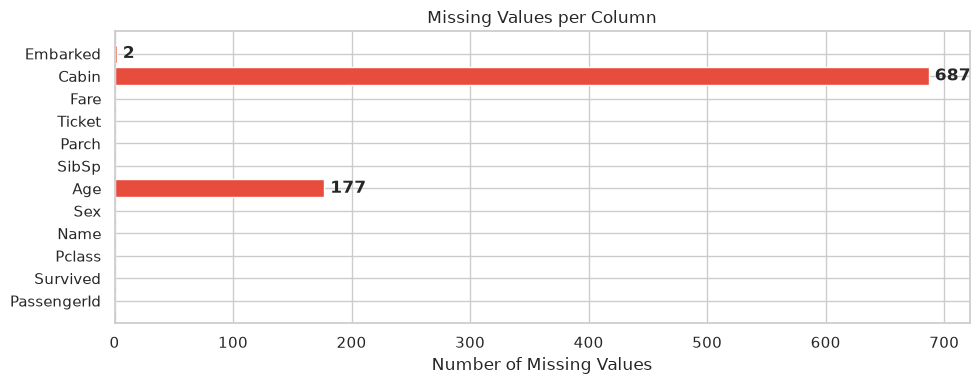

In [7]:
# Visualize the missing values
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#e74c3c" if df[col].isnull().any() else "#2ecc71" for col in df.columns]

ax.barh(df.columns, df.isnull().sum(), color=colors)
ax.set_xlabel("Number of Missing Values")
ax.set_title("Missing Values per Column")
for i, v in enumerate(df.isnull().sum()):
    if v>0:
        ax.text(v+5, i, str(v), va="center", fontweight="bold")
plt.tight_layout()
plt.show()

Key observations:

    - Cabin has ~77% missing values — too many to impute reliably, we'll likely drop it
    - Age has ~20% missing — we can impute using group medians
    - Embarked has only 2 missing values — easy to fill with the mode


## 5. Target Variable Analysis


Survival rate: 38.38%
Death rate: 61.62%


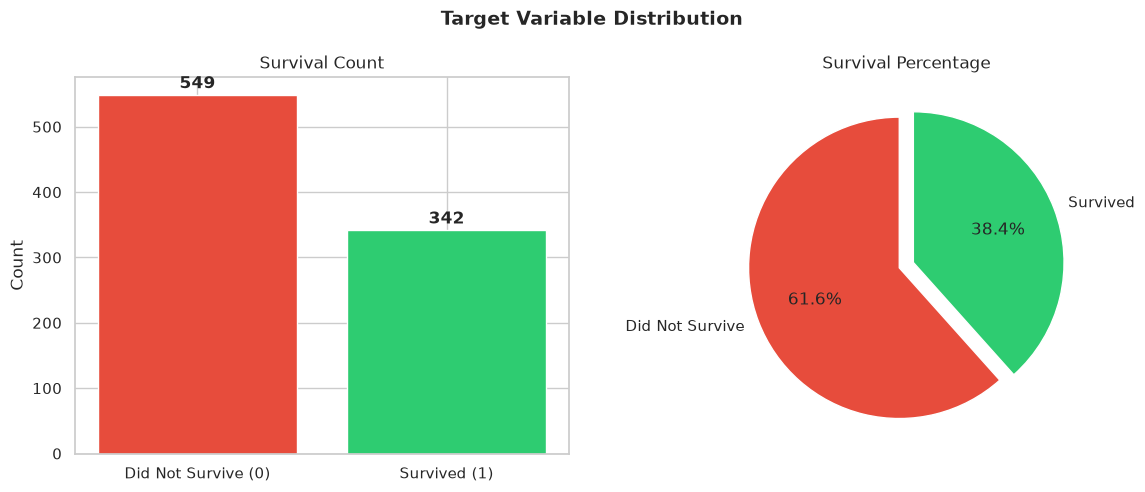

In [8]:
 # Survival Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# count plot
survived_counts = df["Survived"].value_counts()
axes[0].bar(["Did Not Survive (0)", "Survived (1)"], survived_counts.values, color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Survival Count")
axes[0].set_ylabel("Count")

for i, v in enumerate(survived_counts.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

# Pie Chart
axes[1].pie(survived_counts.values, labels=["Did Not Survive", "Survived"],
            autopct="%1.1f%%", colors=["#e74c3c", "#2ecc71"],
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title("Survival Percentage")

plt.suptitle("Target Variable Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show

print(f"\nSurvival rate: {df['Survived'].mean():.2%}")
print(f"Death rate: {1 - df['Survived'].mean():.2%}")


## 6. Univariate Analysis — Numerical Features

In [9]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

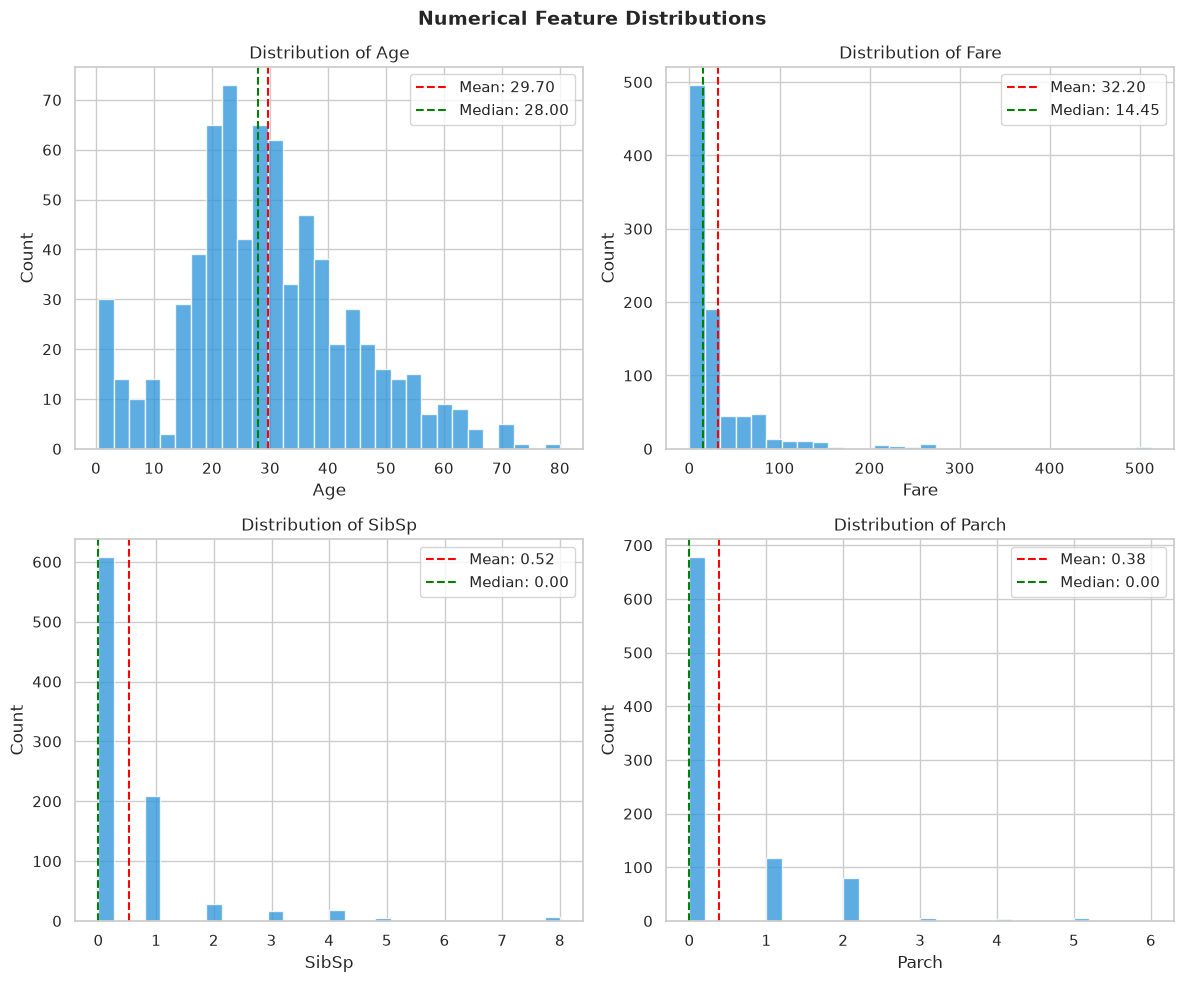

In [10]:
# Distribution of numerical features
numerical_cols = ["Age", "Fare", "SibSp", "Parch"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()


for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=30, color="#3498db", edgecolor="white", alpha=0.8)
    axes[i].axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean: {df[col].mean():.2f}")
    axes[i].axvline(df[col].median(), color="green", linestyle="--", label=f"Median: {df[col].median():.2f}")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].legend()

plt.suptitle("Numerical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

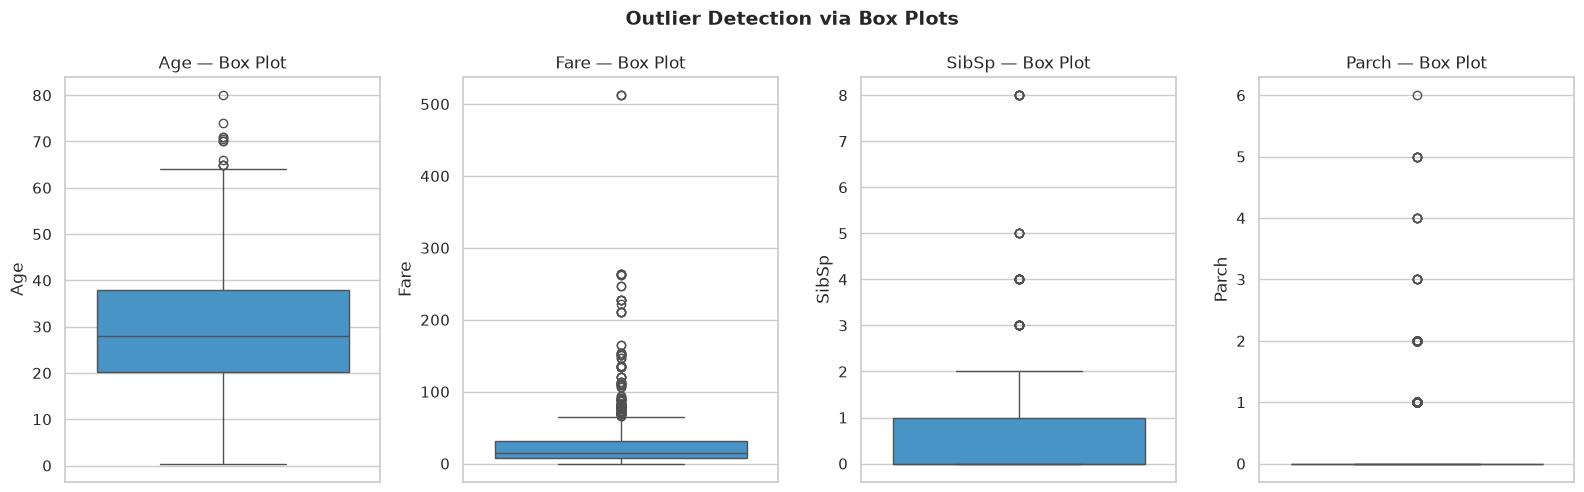

In [11]:
# Box plots to check for outliers
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="#3498db")
    axes[i].set_title(f"{col} — Box Plot")

plt.suptitle("Outlier Detection via Box Plots", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

- Age: roughly normally distributed, centered around ~30. Some outliers at high ages.
- Fare: heavily right-skewed with significant outliers. A few passengers paid very high fares.
- SibSp & Parch: most passengers traveled alone or with 1-2 family members

## 7. Univariate Analysis — Categorical Features

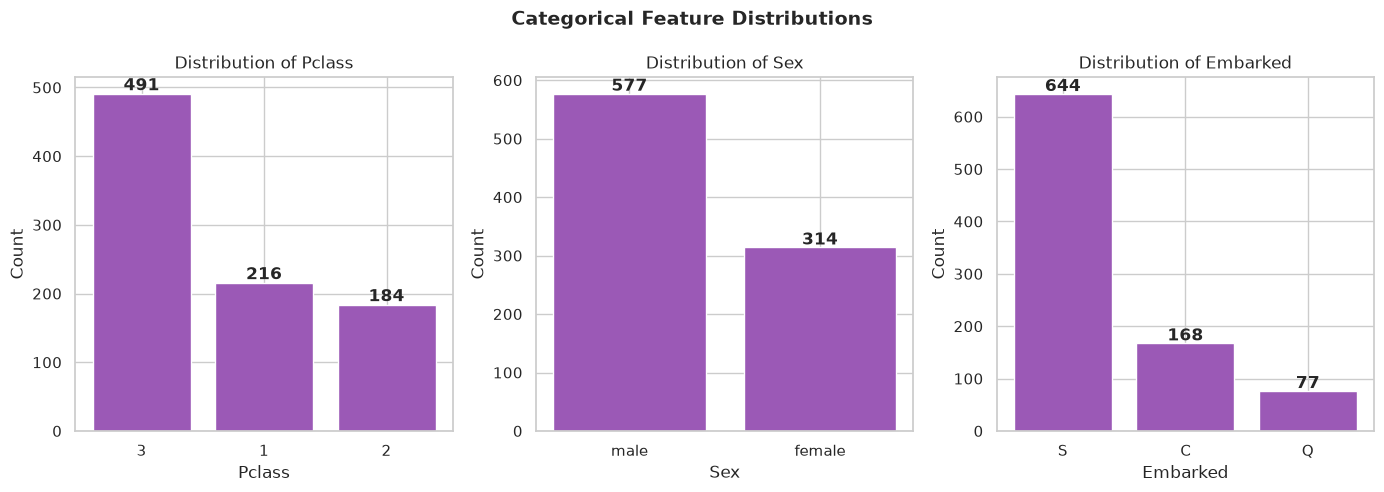

In [12]:
# Distribution of categorical features
categorical_cols = ["Pclass", "Sex", "Embarked"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values, color="#9b59b6", edgecolor="white")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 5, str(v), ha="center", fontweight="bold")

plt.suptitle("Categorical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Observations:**

- Pclass: majority of passengers were in 3rd class
- Sex: more male passengers than female
- Embarked: most passengers boarded at Southampton (S)


### 8. Bivariate Analysis — Survival vs Features

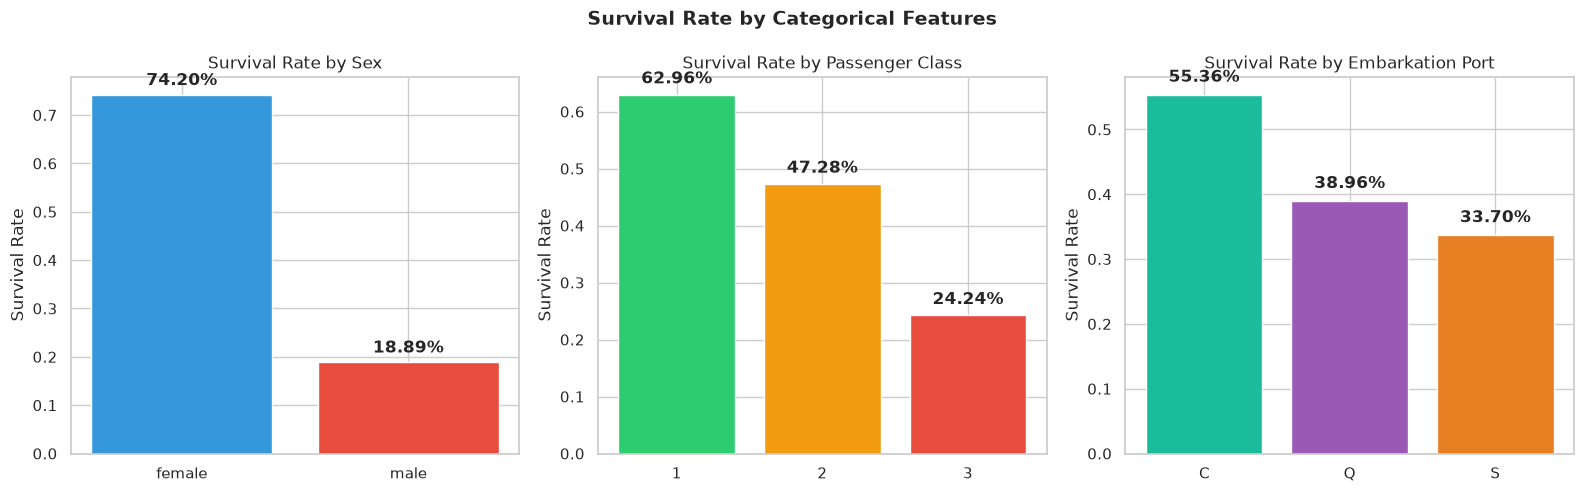

In [13]:
# Survival rate by Sex
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# By Sex
survival_by_sex = df.groupby("Sex")["Survived"].mean()
axes[0].bar(survival_by_sex.index, survival_by_sex.values, color=["#3498db", "#e74c3c"])
axes[0].set_title("Survival Rate by Sex")
axes[0].set_ylabel("Survival Rate")
for i, v in enumerate(survival_by_sex.values):
    axes[0].text(i, v + 0.02, f"{v:.2%}", ha="center", fontweight="bold")

# By Pclass
survival_by_class = df.groupby("Pclass")["Survived"].mean()
axes[1].bar(survival_by_class.index.astype(str), survival_by_class.values,
            color=["#2ecc71", "#f39c12", "#e74c3c"])
axes[1].set_title("Survival Rate by Passenger Class")
axes[1].set_ylabel("Survival Rate")
for i, v in enumerate(survival_by_class.values):
    axes[1].text(i, v + 0.02, f"{v:.2%}", ha="center", fontweight="bold")

# By Embarked
survival_by_embarked = df.groupby("Embarked")["Survived"].mean()
axes[2].bar(survival_by_embarked.index, survival_by_embarked.values,
            color=["#1abc9c", "#9b59b6", "#e67e22"])
axes[2].set_title("Survival Rate by Embarkation Port")
axes[2].set_ylabel("Survival Rate")
for i, v in enumerate(survival_by_embarked.values):
    axes[2].text(i, v + 0.02, f"{v:.2%}", ha="center", fontweight="bold")

plt.suptitle("Survival Rate by Categorical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

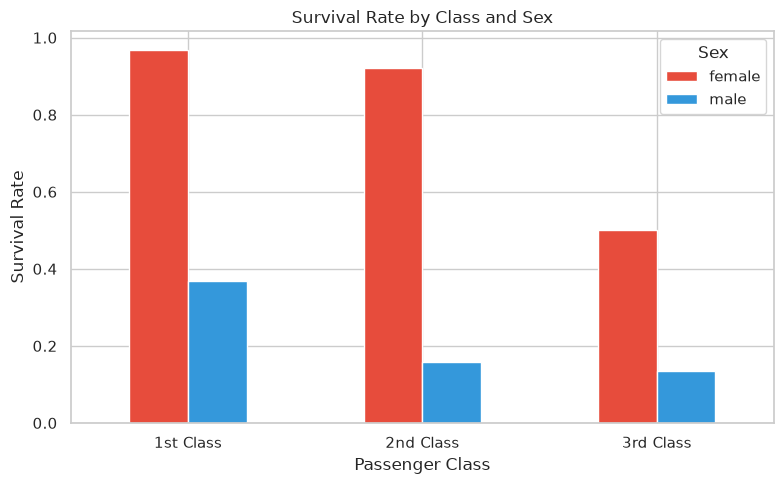

In [14]:
# Survival by Sex and Pclass combined
fig, ax = plt.subplots(figsize=(8, 5))
survival_grouped = df.groupby(["Pclass", "Sex"])["Survived"].mean().unstack()
survival_grouped.plot(kind="bar", ax=ax, color=["#e74c3c", "#3498db"])
ax.set_title("Survival Rate by Class and Sex")
ax.set_ylabel("Survival Rate")
ax.set_xlabel("Passenger Class")
ax.set_xticklabels(["1st Class", "2nd Class", "3rd Class"], rotation=0)
ax.legend(title="Sex")
plt.tight_layout()
plt.show()

**Key findings:**

- Women had a much higher survival rate (~74%) compared to men (~19%) — "women and children first"
- 1st class passengers survived at a much higher rate (~63%) than 3rd class (~24%)
- Cherbourg passengers had the highest survival rate — likely because more 1st class passengers boarded the

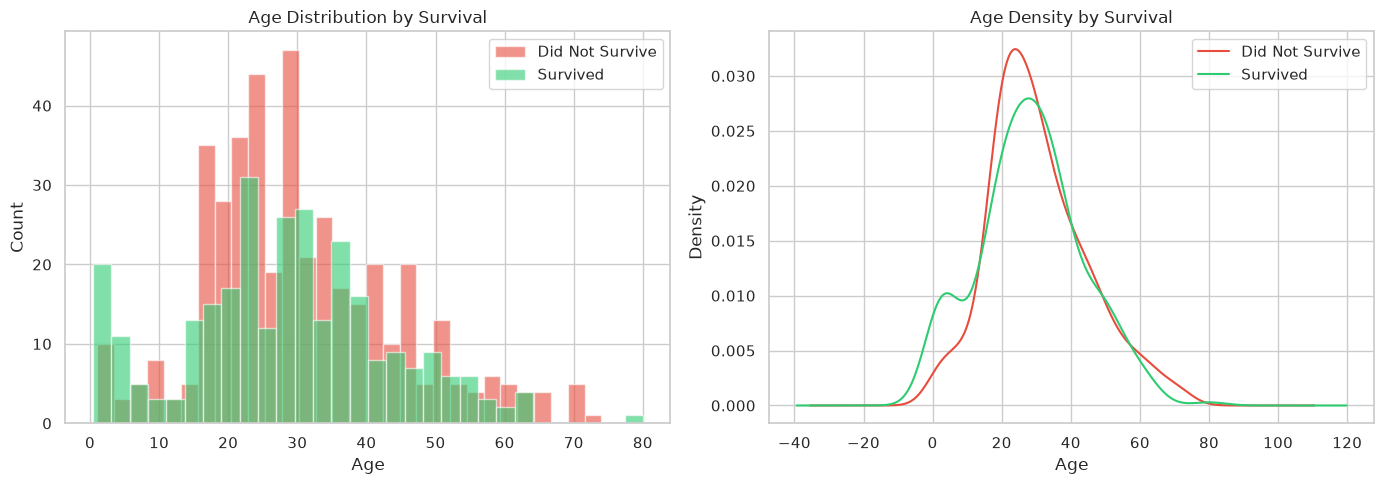

In [15]:


# Age distribution by survival
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overlapping histograms
axes[0].hist(df[df["Survived"] == 0]["Age"].dropna(), bins=30, alpha=0.6,
             color="#e74c3c", label="Did Not Survive", edgecolor="white")
axes[0].hist(df[df["Survived"] == 1]["Age"].dropna(), bins=30, alpha=0.6,
             color="#2ecc71", label="Survived", edgecolor="white")
axes[0].set_title("Age Distribution by Survival")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].legend()

# KDE plot
df[df["Survived"] == 0]["Age"].dropna().plot.kde(ax=axes[1], color="#e74c3c",
                                                  label="Did Not Survive")
df[df["Survived"] == 1]["Age"].dropna().plot.kde(ax=axes[1], color="#2ecc71",
                                                  label="Survived")
axes[1].set_title("Age Density by Survival")
axes[1].set_xlabel("Age")
axes[1].legend()

plt.tight_layout()
plt.show()



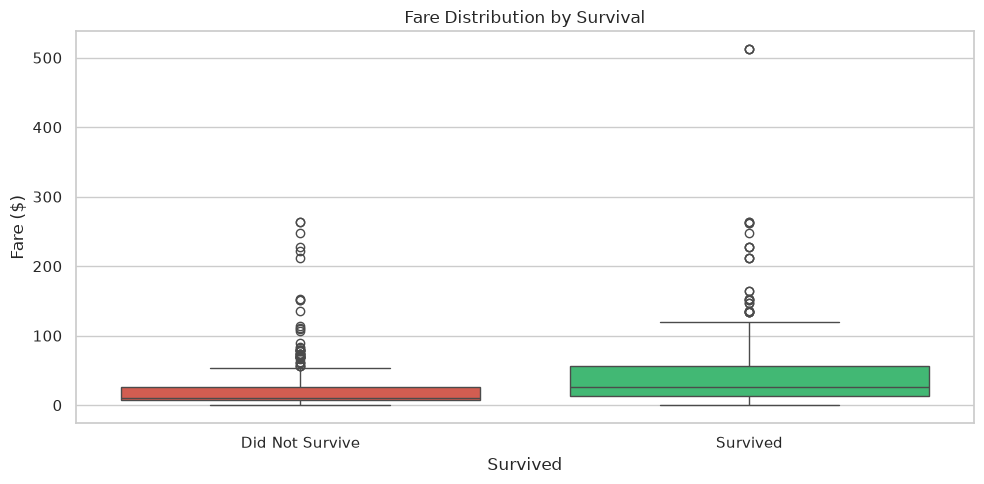

Average fare — Survived: $48.40
Average fare — Did Not Survive: $22.12


In [16]:

# Fare distribution by survival
fig, ax = plt.subplots(figsize=(10, 5))

# Fix 1: Add hue and legend=False to address the palette warning
sns.boxplot(x="Survived", y="Fare", data=df, 
            hue="Survived", palette=["#e74c3c", "#2ecc71"], 
            legend=False, ax=ax)

# Fix 2: Set tick positions before labels
ax.set_xticks([0, 1])
ax.set_xticklabels(["Did Not Survive", "Survived"])

ax.set_title("Fare Distribution by Survival")
ax.set_ylabel("Fare ($)")
plt.tight_layout()
plt.show()

# Print average fares
print(f"Average fare — Survived: ${df[df['Survived']==1]['Fare'].mean():.2f}")
print(f"Average fare — Did Not Survive: ${df[df['Survived']==0]['Fare'].mean():.2f}")


**Observations:**

- Children (age < 10) had a noticeably higher survival rate
- Passengers who survived paid significantly higher fares on average
- This makes sense since higher fares correlate with higher class


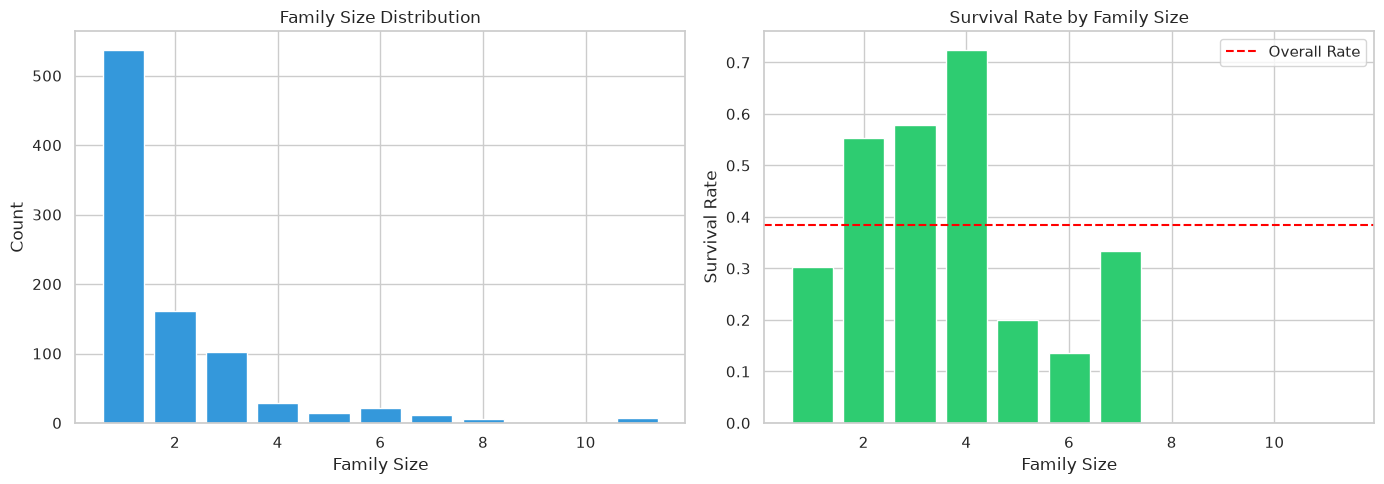

In [17]:
# Create FamilySize feature
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Family size distribution
family_counts = df["FamilySize"].value_counts().sort_index()
axes[0].bar(family_counts.index, family_counts.values, color="#3498db", edgecolor="white")
axes[0].set_title("Family Size Distribution")
axes[0].set_xlabel("Family Size")
axes[0].set_ylabel("Count")

# Survival rate by family size
survival_by_family = df.groupby("FamilySize")["Survived"].mean()
axes[1].bar(survival_by_family.index, survival_by_family.values, color="#2ecc71", edgecolor="white")
axes[1].set_title("Survival Rate by Family Size")
axes[1].set_xlabel("Family Size")
axes[1].set_ylabel("Survival Rate")
axes[1].axhline(y=df["Survived"].mean(), color="red", linestyle="--", label="Overall Rate")
axes[1].legend()

plt.tight_layout()
plt.show()



**Observation: Passengers with small families (2-4 members) had the highest survival rates. Solo travelers and very large families had lower survival rates.**



## 10. Correlation Analysis

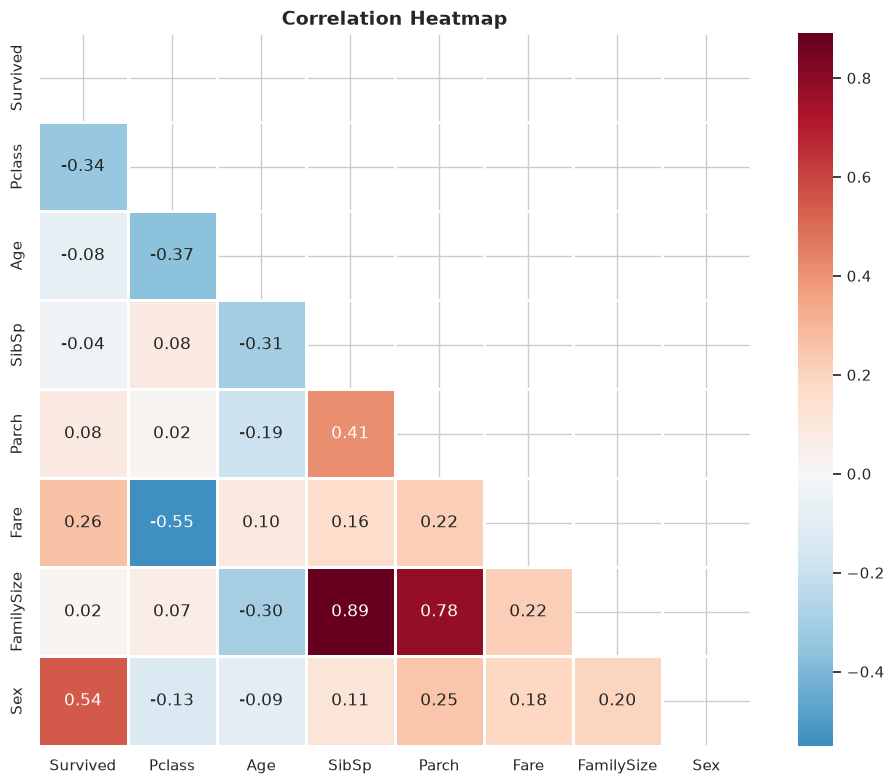

In [18]:


# Correlation heatmap of numerical features
numeric_df = df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize"]].copy()
numeric_df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Upper triangle mask
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=1, ax=ax)
ax.set_title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()



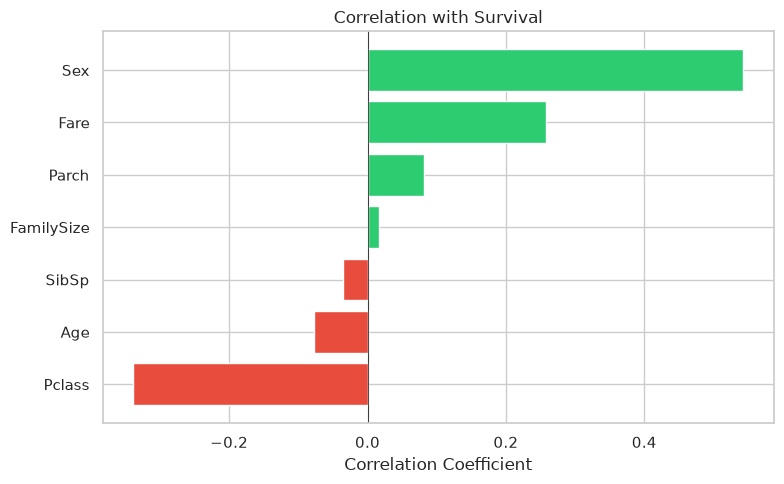

In [19]:
# Correlation with target
target_corr = corr["Survived"].drop("Survived").sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.set_title("Correlation with Survival")
ax.set_xlabel("Correlation Coefficient")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()




**Key correlations with Survival:**
    
- Sex (female): strongest positive correlation — being female significantly increased survival chances
- Fare: positive correlation — higher fares (higher class) led to better survival
- Pclass: negative correlation — lower class number (1st class) = higher survival
- Age: slight negative correlation — younger passengers had slightly better chances



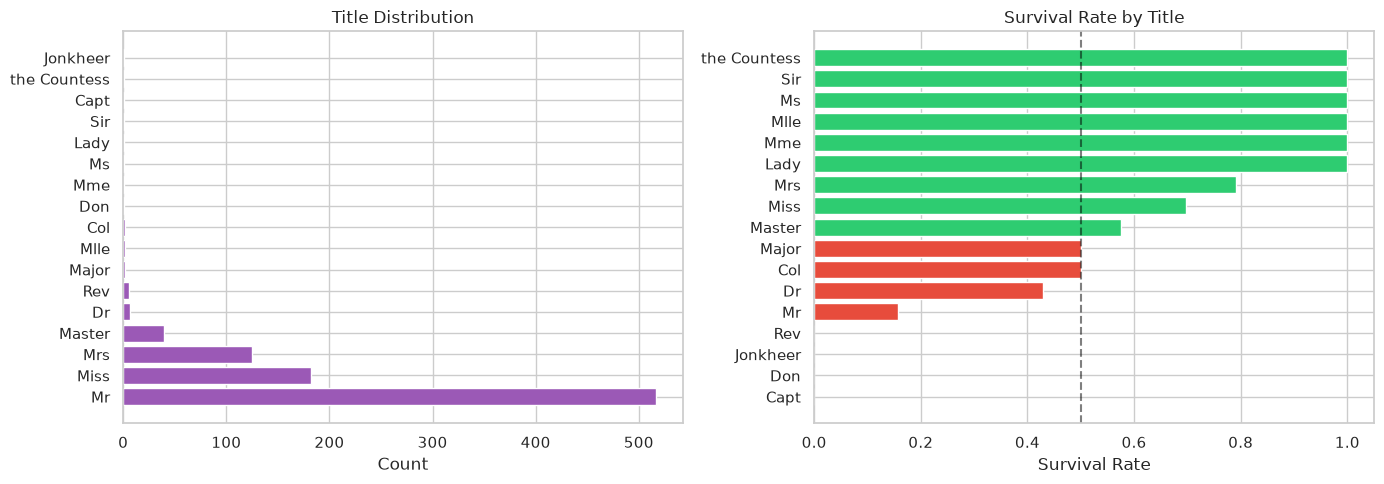

In [20]:
# Extract title from Name
df["Title"] = df["Name"].apply(lambda x: x.split(",")[1].split(".")[0].strip())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Title distribution
title_counts = df["Title"].value_counts()
axes[0].barh(title_counts.index, title_counts.values, color="#9b59b6")
axes[0].set_title("Title Distribution")
axes[0].set_xlabel("Count")

# Survival rate by title
survival_by_title = df.groupby("Title")["Survived"].mean().sort_values()
colors = ["#2ecc71" if v > 0.5 else "#e74c3c" for v in survival_by_title.values]
axes[1].barh(survival_by_title.index, survival_by_title.values, color=colors)
axes[1].set_title("Survival Rate by Title")
axes[1].set_xlabel("Survival Rate")
axes[1].axvline(x=0.5, color="black", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 11. Summary of EDA Findings

# Titanic Survival Analysis - Key Findings

| Finding | Detail |
|---------|--------|
| **Class imbalance** | ~38% survived, ~62% did not |
| **Missing data** | Cabin (77%), Age (20%), Embarked (<1%) |
| **Sex is the strongest predictor** | Females survived at ~74%, males at ~19% |
| **Class matters** | 1st class: 63% survival vs 3rd class: 24% |
| **Age** | Children had higher survival; elderly had lower |
| **Fare** | Survivors paid significantly higher fares |
| **Family size** | Small families (2-4) had the best survival rates |
| **Title** | Mrs, Miss, Master had high survival; Mr had low |
| **Embarkation** | Cherbourg had higher survival (more 1st class) |

# Titanic Survival Prediction — Data Cleaning & Feature Engineering

**What you'll learn:**

- Handling missing values with different strategies
- Encoding categorical variables
- Feature engineering (creating new meaningful features)
- Preparing data for machine learning


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  # Added Plotly as suggested by the maintainer



In [23]:
# Check missing values before cleaning
print("Missing values before cleaning:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values before cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
FamilySize       0
Title            0
dtype: int64

Total missing: 866


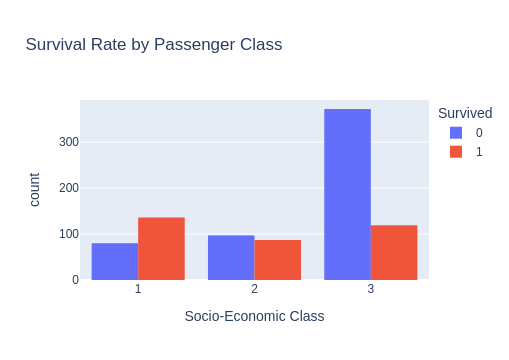

In [24]:
# Fill missing age records with the median age to prevent data loss during modeling
df['Age'] = df['Age'].fillna(df['Age'].median())

fig = px.histogram(
    df, 
    x="Pclass", 
    color="Survived", 
    barmode="group",
    title="Survival Rate by Passenger Class",
    labels={"Pclass": "Socio-Economic Class", "count": "Passenger Count"}
)

# Display the interactive chart
fig.show()


## 2. Handle Missing Values

2.1 Cabin — Drop it

Cabin has ~77% missing values. We can't reliably impute this, so we'll drop it. However, let's first check if having a cabin number is predictive.

In [25]:
# Check if having a cabin recorded affects survival
df["HasCabin"] = df["Cabin"].notna().astype(int)

print("Survival rate by HasCabin:")
print(df.groupby("HasCabin")["Survived"].mean())
print("\nPassengers with a cabin number had a much higher survival rate!")
print("We'll keep HasCabin as a feature and drop the raw Cabin column.")

Survival rate by HasCabin:
HasCabin
0    0.299854
1    0.666667
Name: Survived, dtype: float64

Passengers with a cabin number had a much higher survival rate!
We'll keep HasCabin as a feature and drop the raw Cabin column.


In [26]:
# Drop the raw Cabin column
df = df.drop(columns=["Cabin"])

2.2 Age — Impute with Group Median

Instead of filling Age with the overall median (which ignores context), we'll fill it using the median age per (Pclass, Sex) group. This is more accurate because age distributions differ by class and sex.

In [28]:
# Show median age by Pclass and Sex
print("Median age by Pclass and Sex:")
print(df.groupby(["Pclass", "Sex"])["Age"].median())


Median age by Pclass and Sex:
Pclass  Sex   
1       female    32.5
        male      36.0
2       female    28.0
        male      29.0
3       female    28.0
        male      28.0
Name: Age, dtype: float64


In [29]:
# Fill missing Age with group median
df["Age"] = df.groupby(["Pclass", "Sex"])["Age"].transform(
    lambda x: x.fillna(x.median())
)

# Fill any remaining NaN (edge cases) with overall median
df["Age"] = df["Age"].fillna(df["Age"].median())

print(f"Missing Age values after imputation: {df['Age'].isnull().sum()}")

Missing Age values after imputation: 0


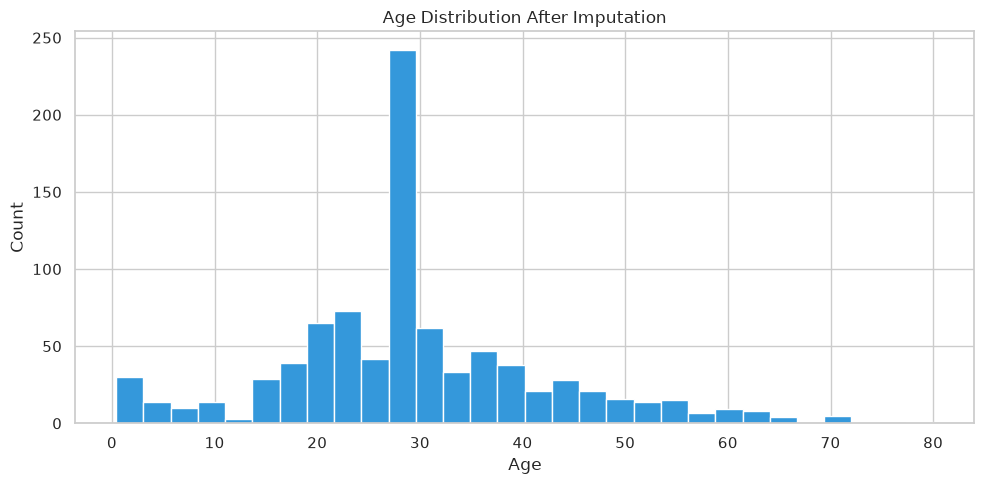

In [30]:
# Visualize Age distribution after imputation
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["Age"], bins=30, color="#3498db", edgecolor="white")
ax.set_title("Age Distribution After Imputation")
ax.set_xlabel("Age")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


2.3 Embarked — Fill with Mode

In [31]:
print(f"Missing Embarked values: {df['Embarked'].isnull().sum()}")
print(f"Mode of Embarked: {df['Embarked'].mode()[0]}")

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

print(f"Missing Embarked after filling: {df['Embarked'].isnull().sum()}")


Missing Embarked values: 2
Mode of Embarked: S
Missing Embarked after filling: 0


In [32]:
# Confirm no missing values remain
print("Missing values after cleaning:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
FamilySize     0
Title          0
HasCabin       0
dtype: int64

Total missing: 0


## 3. Feature Engineering

In [33]:
# Extract title from Name
df["Title"] = df["Name"].apply(lambda x: x.split(",")[1].split(".")[0].strip())

print("Title counts:")
print(df["Title"].value_counts())

Title counts:
Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


In [34]:
# Group rare titles together
title_mapping = {
    "Mr": "Mr",
    "Miss": "Miss",
    "Mrs": "Mrs",
    "Master": "Master",
}

df["Title"] = df["Title"].apply(lambda x: title_mapping.get(x, "Rare"))

print("\nTitle counts after grouping:")
print(df["Title"].value_counts())
print("\nSurvival rate by Title:")
print(df.groupby("Title")["Survived"].mean().sort_values(ascending=False))


Title counts after grouping:
Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

Survival rate by Title:
Title
Mrs       0.792000
Miss      0.697802
Master    0.575000
Rare      0.444444
Mr        0.156673
Name: Survived, dtype: float64


3.2 Family Size and IsAlone

In [36]:
# Family size
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Is alone flag
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

print(f"Solo travelers: {df['IsAlone'].sum()} ({df['IsAlone'].mean():.1%})")
print(f"\nSurvival rate — Alone: {df[df['IsAlone']==1]['Survived'].mean():.2%}")
print(f"Survival rate — With Family: {df[df['IsAlone']==0]['Survived'].mean():.2%}")

Solo travelers: 537 (60.3%)

Survival rate — Alone: 30.35%
Survival rate — With Family: 50.56%


3.3 Age Groups

In [38]:


# Bin ages into groups
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 80],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

print("Age group distribution:")
print(df["AgeGroup"].value_counts().sort_index())
print("\nSurvival rate by Age Group:")
print(df.groupby("AgeGroup")["Survived"].mean())



Age group distribution:
AgeGroup
Child           69
Teen            70
Young Adult    535
Adult          195
Senior          22
Name: count, dtype: int64

Survival rate by Age Group:
AgeGroup
Child          0.579710
Teen           0.428571
Young Adult    0.353271
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64


3.4 Fare Bins

In [39]:
df["FareBin"] = pd.qcut(
    df["Fare"], q=4, labels=["Low", "Medium", "High", "Very High"]
)

print("Survival rate by Fare Bin:")
print(df.groupby("FareBin")["Survived"].mean())

Survival rate by Fare Bin:
FareBin
Low          0.197309
Medium       0.303571
High         0.454955
Very High    0.581081
Name: Survived, dtype: float64


## 4. Encode Categorical Variables

In [40]:
# View current dtypes
print("Current columns and types:")
print(df.dtypes)
print(f"\nShape: {df.shape}")

Current columns and types:
PassengerId       int64
Survived          int64
Pclass            int64
Name                str
Sex                 str
Age             float64
SibSp             int64
Parch             int64
Ticket              str
Fare            float64
Embarked            str
FamilySize        int64
Title               str
HasCabin          int64
IsAlone           int64
AgeGroup       category
FareBin        category
dtype: object

Shape: (891, 17)


In [41]:
# Encode Sex
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

# One-hot encode Embarked, Title, AgeGroup, FareBin
df = pd.get_dummies(df, columns=["Embarked", "Title", "AgeGroup", "FareBin"], drop_first=True, dtype=int)

print(f"Shape after encoding: {df.shape}")
df.head()

Shape after encoding: (891, 26)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Title_Mr,Title_Mrs,Title_Rare,AgeGroup_Teen,AgeGroup_Young Adult,AgeGroup_Adult,AgeGroup_Senior,FareBin_Medium,FareBin_High,FareBin_Very High
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,...,1,0,0,0,1,0,0,0,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,...,0,1,0,0,0,1,0,0,0,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,...,0,0,0,0,1,0,0,1,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,...,0,1,0,0,1,0,0,0,0,1
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,...,1,0,0,0,1,0,0,1,0,0


## 5. Drop Unnecessary Columns

In [42]:
# Drop columns not useful for modeling
drop_cols = ["PassengerId", "Name", "Ticket"]
df = df.drop(columns=drop_cols)

print(f"Final shape: {df.shape}")
print(f"\nFinal columns:")
print(df.columns.tolist())

Final shape: (891, 23)

Final columns:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'HasCabin', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeGroup_Teen', 'AgeGroup_Young Adult', 'AgeGroup_Adult', 'AgeGroup_Senior', 'FareBin_Medium', 'FareBin_High', 'FareBin_Very High']


In [43]:
# Final check
print("Missing values:")
print(df.isnull().sum().sum())
print("\nData types:")
print(df.dtypes)


Missing values:
0

Data types:
Survived                  int64
Pclass                    int64
Sex                       int64
Age                     float64
SibSp                     int64
Parch                     int64
Fare                    float64
FamilySize                int64
HasCabin                  int64
IsAlone                   int64
Embarked_Q                int64
Embarked_S                int64
Title_Miss                int64
Title_Mr                  int64
Title_Mrs                 int64
Title_Rare                int64
AgeGroup_Teen             int64
AgeGroup_Young Adult      int64
AgeGroup_Adult            int64
AgeGroup_Senior           int64
FareBin_Medium            int64
FareBin_High              int64
FareBin_Very High         int64
dtype: object


## 6. Save Cleaned Data

In [ ]:


# Save the cleaned and engineered dataset
df.to_csv("data/titanic_cleaned.csv", index=False)
print("Cleaned dataset saved to data/titanic_cleaned.csv")
print(f"Final shape: {df.shape}")
df.head()

